In [4]:
import sympy as sp
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

Линеаризуем систему и посчитаем точки равновесия с помощью sympy, а затем просимулируем линеаризованную систему с помощью scipy.

In [40]:
import numpy as np
from scipy.optimize import fsolve

# Параметры системы
m, g = 1.0, 9.81
k1, k2, k3 = 50.0, 50.0, 50.0
L01, L02, L03 = 0.5, 0.5, 0.5
mu = np.radians(80)
Lw, Lf, Lt = 1.0, 1.0, 1.2

anchor1 = np.array([Lw * np.cos(mu), Lw * np.sin(mu)])
anchor2 = np.array([Lf, 0.0])
anchor3 = np.array([0.0, Lt])

def get_acceleration(pos):
    r1, r2, r3 = pos - anchor1, pos - anchor2, pos - anchor3
    dist1, dist2, dist3 = np.linalg.norm(r1), np.linalg.norm(r2), np.linalg.norm(r3)

    f1 = -k1 * (dist1 - L01) * (r1 / dist1)
    f2 = -k2 * (dist2 - L02) * (r2 / dist2)
    f3 = -k3 * (dist3 - L03) * (r3 / dist3)

    return (f1 + f2 + f3 + np.array([0, -m * g])) / m

dt, steps = 0.01, 1000
p0, v0 = np.array([0.563, 0.348]), np.array([0.0, 0.0]) # Начальный условие подобраны примерно как в линеаризации
method_names = ["Explicit Euler", "Implicit Euler", "Symplectic Euler", "Vanilla Verlet"]

pos_data = {name: np.zeros((steps, 2)) for name in method_names}
vel_data = {name: np.zeros((steps, 2)) for name in method_names}

for name in method_names:
    pos_data[name][0], vel_data[name][0] = p0, v0

for i in range(steps - 1):
    # Explicit
    a_exp = get_acceleration(pos_data["Explicit Euler"][i])
    pos_data["Explicit Euler"][i+1] = pos_data["Explicit Euler"][i] + vel_data["Explicit Euler"][i] * dt
    vel_data["Explicit Euler"][i+1] = vel_data["Explicit Euler"][i] + a_exp * dt

    # Implicit
    def impl_func(x):
        p, v = x[:2], x[2:]
        return np.concatenate([
            p - pos_data["Implicit Euler"][i] - v * dt,
            v - vel_data["Implicit Euler"][i] - get_acceleration(p) * dt
        ])
    sol = fsolve(impl_func, np.concatenate([pos_data["Implicit Euler"][i], vel_data["Implicit Euler"][i]]))
    pos_data["Implicit Euler"][i+1], vel_data["Implicit Euler"][i+1] = sol[:2], sol[2:]

    # Symplectic
    a_s = get_acceleration(pos_data["Symplectic Euler"][i])
    vel_data["Symplectic Euler"][i+1] = vel_data["Symplectic Euler"][i] + a_s * dt
    pos_data["Symplectic Euler"][i+1] = pos_data["Symplectic Euler"][i] + vel_data["Symplectic Euler"][i+1] * dt

    # Verlet
    pc = pos_data["Vanilla Verlet"][i]
    ac = get_acceleration(pc)
    pp = pos_data["Vanilla Verlet"][i-1] if i > 0 else pc - v0*dt + 0.5*ac*dt**2
    pos_data["Vanilla Verlet"][i+1] = 2*pc - pp + ac*dt**2
    # Восстановление скорости для Verlet (центральная разность)
    if i > 0:
        vel_data["Vanilla Verlet"][i] = (pos_data["Vanilla Verlet"][i+1] - pos_data["Vanilla Verlet"][i-1]) / (2 * dt)

# PАСЧЕТ ЭНЕРГИИ
def get_total_energy(pos, vel):
    e_kin = 0.5 * m * np.sum(vel**2)
    dist1 = np.linalg.norm(pos - anchor1)
    dist2 = np.linalg.norm(pos - anchor2)
    dist3 = np.linalg.norm(pos - anchor3)

    e_pot_spring = (0.5 * k1 * (dist1 - L01)**2 +
                    0.5 * k2 * (dist2 - L02)**2 +
                    0.5 * k3 * (dist3 - L03)**2)

    e_pot_grav = m * g * pos[1]
    return e_kin + e_pot_spring + e_pot_grav

energy_data = {name: np.zeros(steps) for name in method_names}
for name in method_names:
    for i in range(steps):
        energy_data[name][i] = get_total_energy(pos_data[name][i], vel_data[name][i])

Изобаразим графики энергии и траектоории.

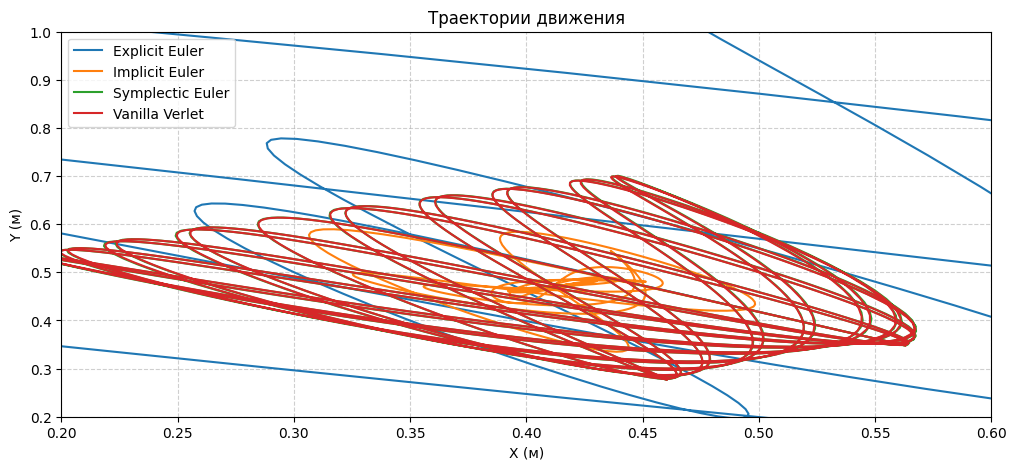

In [41]:
import matplotlib.pyplot as plt
# ВИЗУАЛИЗАЦИЯ ТРАЕКТОРИЙ
plt.figure(figsize=(12, 5))

for name in method_names:
    plt.plot(pos_data[name][:, 0], pos_data[name][:, 1], label=name, lw=1.5)

plt.title("Траектории движения")
plt.xlabel("X (м)")
plt.ylabel("Y (м)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(0.2, 0.6)
plt.ylim(0.2, 1)

plt.show()

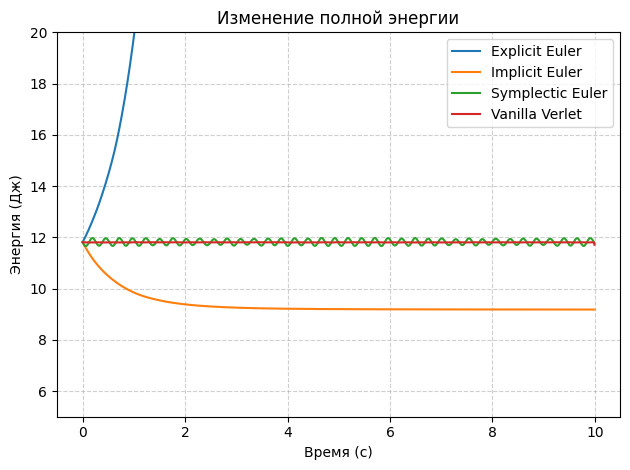

In [42]:
# ВИЗУАЛИЗАЦИЯ ЭНЕРГИИ
time_axis = np.arange(steps) * dt
for name in method_names:
    plt.plot(time_axis, energy_data[name], label=name)

plt.title("Изменение полной энергии")
plt.xlabel("Время (с)")
plt.ylabel("Энергия (Дж)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(5, 20)

plt.tight_layout()
plt.show()